# Gale-Shapley algorithm for Crop Rotation planning

Import libraries needed to execute the code.

In [1]:
import json
from typing import Dict, List, Tuple, Optional, Any
import random
from copy import deepcopy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from collections import defaultdict
import plotly.graph_objects as go

## Loading the dataset

Loads `crops.json` and `fields.json` into `crops` and `fields`.

In [2]:
with open("data/crops.json") as f:
    crops = json.load(f)

with open("data/fields.json") as f:
    fields = json.load(f)

crops_df = pd.DataFrame(crops)
fields_df = pd.DataFrame(fields)

print("Crop characteristics:")
display(crops_df)

print("\nField characteristics:")
display(fields_df)

Crop characteristics:


,name,water_demand,nitrogen_demand,sun_requirement,soil_pH_min,soil_pH_max,family,is_legume
0,Wheat,0.5,0.6,0.8,6.0,7.5,Poaceae,0
1,Corn,0.8,0.9,1.0,5.8,7.0,Poaceae,0
2,Soybean,0.6,0.3,0.9,6.0,7.0,Fabaceae,1
3,Potato,0.7,0.7,0.8,5.0,6.5,Solanaceae,0
4,Tomato,0.7,0.8,1.0,5.5,7.0,Solanaceae,0
5,Alfalfa,0.6,0.2,0.9,6.5,7.5,Fabaceae,1
6,Barley,0.4,0.5,0.8,6.0,7.5,Poaceae,0
7,Sunflower,0.5,0.6,1.0,6.0,7.5,Asteraceae,0
8,Pea,0.5,0.3,0.7,6.0,7.5,Fabaceae,1
9,Canola,0.6,0.7,0.9,5.5,7.0,Brassicaceae,0



Field characteristics:


,name,soil_type,soil_pH,water_availability,sun_exposure,nutrient_level,last_crop_family
0,Field0,loam,6.8,0.7,0.9,0.8,Poaceae
1,Field1,sandy,6.2,0.4,1.0,0.5,Fabaceae
2,Field2,clay,7.2,0.8,0.8,0.9,Solanaceae
3,Field3,loam,6.5,0.6,0.7,0.7,Brassicaceae
4,Field4,silty,6.9,0.7,0.9,0.8,Asteraceae
5,Field5,sandy,5.8,0.3,1.0,0.4,Poaceae
6,Field6,clay,7.0,0.9,0.8,0.9,Fabaceae
7,Field7,loam,6.3,0.5,0.8,0.6,Solanaceae
8,Field8,silty,6.7,0.6,0.9,0.7,Brassicaceae
9,Field9,loam,7.1,0.7,1.0,0.8,Asteraceae


## Utility and Scoring Functions

Below we define the scoring functions used to compute the preferences between crops and fields sets.

The functions are the following:

- `clamp` - Keeps values within a fixed range $[0,1]$.
- `similarity` - Measures the similarity between two values.
- `pH_match` - Scores soil pH compatibility.
- `crop_to_field_score` - Computes the preferences from crops to fields.
- `field_to_crop_score` - Computes the preferences from fields to crops.
- `generate_preferences` - Creates a tuple contaning all the preferences between crops and fields.

In [3]:
def clamp(x, min_val=0.0, max_val=1.0):
    return max(min_val, min(x, max_val))

def similarity(a: float, b: float) -> float:
    return 1 - abs(a - b)

def pH_match(field_pH: float, crop_min: float, crop_max: float) -> float:
    if crop_min <= field_pH <= crop_max:
        return 1.0
    distance = min(abs(field_pH - crop_min), abs(field_pH - crop_max))
    return clamp(1 - (distance / 1.5))

def crop_to_field_score(crop: Dict, field: Dict) -> float:
    ph_score = pH_match(field["soil_pH"], crop["soil_pH_min"], crop["soil_pH_max"])
    if ph_score == 0:
        return 0.0

    water_score = similarity(crop["water_demand"], field["water_availability"])
    sun_score = similarity(crop["sun_requirement"], field["sun_exposure"])
    nutrient_score = similarity(crop["nitrogen_demand"], field["nutrient_level"])

    score = (
        0.30 * water_score +
        0.25 * sun_score +
        0.25 * nutrient_score +
        0.20 * ph_score
    )
    return clamp(score)

def field_to_crop_score(crop: Dict, field: Dict) -> float:
    if crop["family"] == field.get("last_crop_family"):
        return 0.0

    score = 0.0

    if crop.get("is_legume"):
        score += 0.4

    nutrient_gap = crop["nitrogen_demand"] - field["nutrient_level"]
    if nutrient_gap > 0:
        score += clamp(1 - nutrient_gap)
    else:
        score += 1.0

    score += similarity(crop["water_demand"], field["water_availability"])

    max_possible = 0.4 + 1.0 + 1.0
    return clamp(score / max_possible)


def generate_preferences(crops: List[Dict], fields: List[Dict]) -> Tuple[Dict[str, List[str]], Dict[str, List[str]]]:
    crop_prefs = {}
    field_prefs = {}

    for crop in crops:
        scores = [(field["name"], crop_to_field_score(crop, field)) for field in fields]
        scores.sort(key=lambda x: x[1], reverse=True)
        crop_prefs[crop["name"]] = [name for name, _ in scores]

    for field in fields:
        scores = [(crop["name"], field_to_crop_score(crop, field)) for crop in crops]
        scores.sort(key=lambda x: x[1], reverse=True)
        field_prefs[field["name"]] = [name for name, _ in scores]

    return crop_prefs, field_prefs

Here you can visualize a matrix containing the preferences between crops and fields.

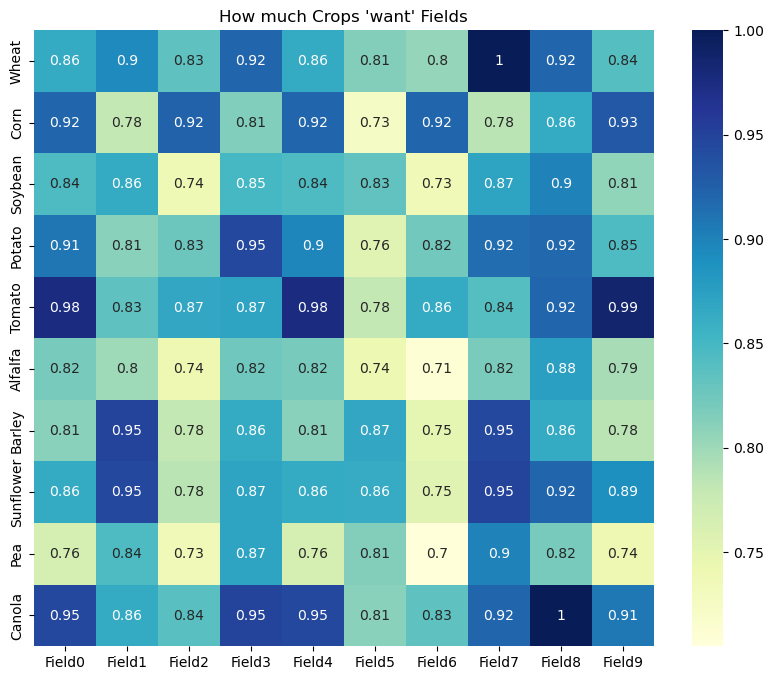

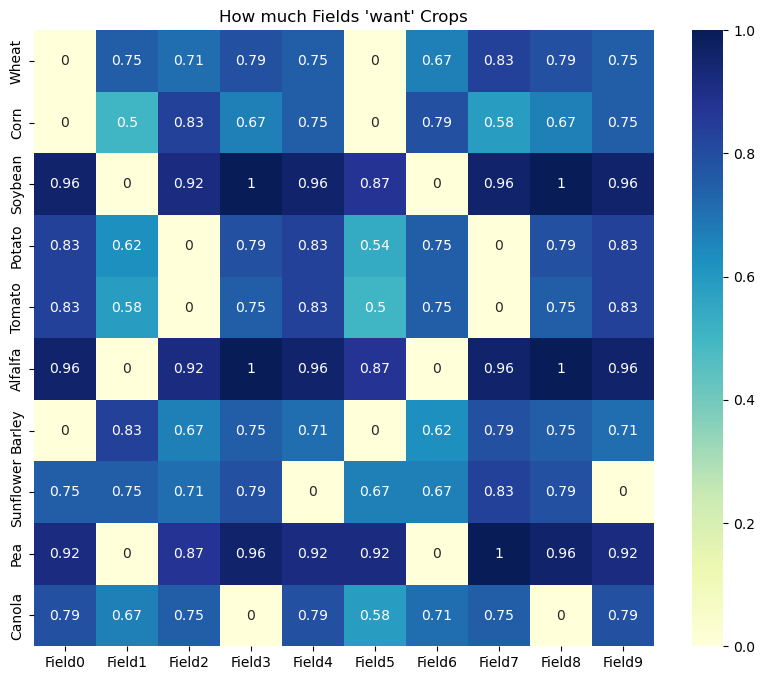

In [4]:
def plot_preference_heatmap(crops, fields, score_func, title="Compatibility"):
    matrix = np.zeros((len(crops), len(fields)))
    crop_names = [c["name"] for c in crops]
    field_names = [f["name"] for f in fields]

    for i, crop in enumerate(crops):
        for j, field in enumerate(fields):
            matrix[i, j] = score_func(crop, field)
            
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, xticklabels=field_names, yticklabels=crop_names, cmap="YlGnBu")
    plt.title(title)
    plt.show()

# Visualize Crop -> Field preferences
plot_preference_heatmap(crops, fields, crop_to_field_score, "How much Crops 'want' Fields")
# Visualize Field -> Crop preferences
plot_preference_heatmap(crops, fields, field_to_crop_score, "How much Fields 'want' Crops")

## Yield and Field Management

Here we define some functions which are used to compute the yield of each filed for the given crop-field assignemnt (used to evaluate the performance of the assigment) and to update the fileds' properties after a crop has been planted on it.

In [5]:
def compute_yield(crop, field):
    compatibility = crop_to_field_score(crop, field)
    nutrient_factor = max(0.0, field.get("nutrient_level", 0.0)) ** 1.5

    water_diff = abs(crop["water_demand"] - field["water_availability"])
    water_factor = max(0.0, 1 - 1.5 * water_diff)

    sun_diff = abs(crop["sun_requirement"] - field["sun_exposure"])
    sun_factor = max(0.0, 1 - sun_diff)

    base_productivity = 1.0
    if crop["name"] == "Corn":
        base_productivity = 1.2
    elif crop["name"] == "Soybean":
        base_productivity = 0.9

    yield_value = base_productivity * compatibility * nutrient_factor * water_factor * sun_factor
    return max(0.0, yield_value)


def update_field(field, crop):
    field = deepcopy(field)
    field["last_crop_family"] = crop["family"]

    if crop.get("is_legume"):
        field["nutrient_level"] = clamp(field.get("nutrient_level", 0.0) + 0.2)
    else:
        field["nutrient_level"] = clamp(
            field.get("nutrient_level", 0.0) - crop.get("nitrogen_demand", 0.0) * 0.15
        )

    field["water_availability"] = clamp(
        field.get("water_availability", 0.0) + random.uniform(-0.1, 0.1)
    )

    return field

## Gale-Shapley

Implementation of the Gale-Shapley algorithm to create a stable matching between crops and fields. 

In [6]:
def gale_shapley(crop_prefs, field_prefs):
    free_crops = list(crop_prefs.keys())
    proposals = {c: [] for c in crop_prefs}
    matches = {}

    field_rank = {
        f: {crop: rank for rank, crop in enumerate(prefs)}
        for f, prefs in field_prefs.items()
    }

    while free_crops:
        crop = free_crops.pop(0)
        prefs = crop_prefs[crop]

        for field in prefs:
            if field in proposals[crop]:
                continue

            proposals[crop].append(field)

            if field not in matches:
                matches[field] = crop
                break
            else:
                current_crop = matches[field]
                if field_rank[field][crop] < field_rank[field][current_crop]:
                    matches[field] = crop
                    free_crops.append(current_crop)
                    break

    return {crop: field for field, crop in matches.items()}

## Greedy

Assings crops to fields in a greedy way by maximiming a score function provided as parameter.

In [7]:
def greedy_matching(crops, fields, score_func):
    remaining_crops = set(c["name"] for c in crops)
    remaining_fields = set(f["name"] for f in fields)
    matches = {}
    while remaining_crops and remaining_fields:
        best_pair = None
        best_score = -1
        for crop in crops:
            if crop["name"] not in remaining_crops:
                continue
            for field in fields:
                if field["name"] not in remaining_fields:
                    continue
                score = score_func(crop, field)
                if score > best_score:
                    best_score = score
                    best_pair = (crop["name"], field["name"])
        if best_pair:
            c, f = best_pair
            matches[c] = f
            remaining_crops.remove(c)
            remaining_fields.remove(f)
    return matches

## Random

Assigns crops to fields randomly, without considering any preference.

In [8]:
def random_matching(crops, fields):
    crop_names = [c["name"] for c in crops]
    field_names = [f["name"] for f in fields]
    random.shuffle(field_names)
    return dict(zip(crop_names, field_names))

## Q-Learning and Ensemble

Here, we implement the Q-learning algorithm, which is a reinforcement learning approach to learn the crop-field assignments which maximizes the reward. We also implement an ensemble of Q-learners to improve the robustness of the learned assignments.

The functions and classes defined in this section are:


- `_bin`, `get_field_id`, `encode_local_state`, `valid_crops_for_field` - Shared Q-learning state helpers.
- `IndependentCropQLearner` - Learner that resolves crop assignments with exploration and conflict handling.
- `simulate_q_learning` - Trains one learner across episodes and seasons.
- `train_ensemble` - Trains multiple learners with different seeds.
- `averaged_q_matrix`, `averaged_q_assignment` - Build ensemble-wide Q estimates and assignments.
- `evaluate_ensemble`, `train_ensemble_and_compare` - Evaluate and package ensemble results.

In [9]:
try:
    from scipy.optimize import linear_sum_assignment
    _HUNGARIAN_AVAILABLE = True
except Exception:
    _HUNGARIAN_AVAILABLE = False

DEFAULT_SEASONS_PER_EPISODE = 40
DEFAULT_EPISODES = 400
DEFAULT_REWARD_CLIP = 2.0

def _bin(value: float, n_bins: int = 4) -> int:
    return min(max(int(value * n_bins), 0), n_bins - 1)

def get_field_id(field: dict) -> str:
    return str(field.get("id", field.get("name")))

def encode_local_state(field: dict) -> tuple:
    return (
        field.get("last_crop_family"),
        _bin(field.get("nutrient_level", 0.0)),
        _bin(field.get("water_availability", 0.0)),
    )

def valid_crops_for_field(field: dict, crops: List[dict]) -> List[int]:
    return [i for i, c in enumerate(crops) if c.get("family") != field.get("last_crop_family")]

class IndependentCropQLearner:
    """
    Each field acts as an independent RL agent.
    The agent selects which crop to plant based on Q-values.
    """

    def __init__(
        self,
        crops: List[dict],
        fields: List[dict],
        alpha: float = 0.05,
        gamma: float = 0.9,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.02,
        decay_step: float = 0.002,
        seed: Optional[int] = None,
        initial_priority_index: int = 0,
    ):
        self.crops = crops
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.decay_step = decay_step
        self._rng = random.Random(seed)
        self.priority_index = initial_priority_index

        # Q-table: one dictionary per field
        self.Q: Dict[str, Dict] = {get_field_id(f): {} for f in fields}

    def _q(self, field_id: str, state: tuple, action: int) -> float:
        """Retrieve Q-value for (state, action)."""
        return self.Q[field_id].get((state, action), 0.0)

    def _select_for_field(self, field: dict, state: tuple) -> Optional[int]:
        """Epsilon-greedy crop selection for a single field."""
        valid = valid_crops_for_field(field, self.crops)
        if not valid:
            return None

        # Exploration
        if self._rng.random() < self.epsilon:
            return self._rng.choice(valid)

        # Exploitation
        fid = get_field_id(field)
        best_q = max((self._q(fid, state, a) for a in valid), default=0.0)
        best = [a for a in valid if self._q(fid, state, a) >= best_q - 1e-9]
        return self._rng.choice(best)

    def resolve_assignment(
        self,
        fields: List[dict],
        states: List[tuple],
        force_greedy: bool = False,
        rotate_priority: bool = True,
    ) -> List[Optional[int]]:
        """
        Resolve crop assignments for all fields simultaneously.
        Handles conflicts when multiple fields select the same crop.
        """
        n = len(fields)
        proposals = [None] * n

        # First proposal for each field
        for i, (field, state) in enumerate(zip(fields, states)):
            valid = valid_crops_for_field(field, self.crops)
            if not valid:
                proposals[i] = None
                continue

            if force_greedy:
                fid = get_field_id(field)
                best_q = max((self._q(fid, state, a) for a in valid), default=0.0)
                best = [a for a in valid if self._q(fid, state, a) >= best_q - 1e-9]
                proposals[i] = self._rng.choice(best)
            else:
                proposals[i] = self._select_for_field(field, state)

        # Ranking for tie-breaking
        ranked = []
        for field, state in zip(fields, states):
            valid = valid_crops_for_field(field, self.crops)
            ranked.append(sorted(valid, key=lambda a: self._q(get_field_id(field), state, a), reverse=True))

        assignment = [None] * n
        taken = set()
        proposal_bids: Dict[int, List[int]] = {}

        # Group fields that proposed the same crop
        for i, p in enumerate(proposals):
            if p is not None:
                proposal_bids.setdefault(p, []).append(i)

        # Resolve conflicts
        for crop_idx, bidders in proposal_bids.items():
            if len(bidders) == 1:
                winner = bidders[0]
            else:
                # Tie-breaking using Q-values + priority rotation
                def bidder_score(i_bid):
                    base = self._q(get_field_id(fields[i_bid]), states[i_bid], crop_idx)
                    if rotate_priority:
                        dist = (i_bid - self.priority_index) % n
                        priority_bonus = (n - dist) / (n * 1000.0)
                    else:
                        priority_bonus = 0.0
                    noise = self._rng.random() * 1e-9
                    return base + priority_bonus + noise

                winner = max(bidders, key=bidder_score)

            assignment[winner] = crop_idx
            taken.add(crop_idx)

        # Fill remaining fields with best available crops
        for i, prefs in enumerate(ranked):
            if assignment[i] is not None:
                continue
            for crop_idx in prefs:
                if crop_idx not in taken:
                    assignment[i] = crop_idx
                    taken.add(crop_idx)
                    break

        # Final fallback for unassigned fields
        all_valid = set(range(len(self.crops)))
        free_crops = list(all_valid - taken)

        for i in range(n):
            if assignment[i] is None:
                valid_free = [c for c in valid_crops_for_field(fields[i], self.crops) if c in free_crops]
                if valid_free:
                    chosen = self._rng.choice(valid_free)
                    assignment[i] = chosen
                    free_crops.remove(chosen)

        return assignment

    def update_q_for_field(self, field: dict, state: tuple, action: Optional[int], reward: float, next_field: dict):
        """Standard Q-learning update rule."""
        if action is None:
            return

        field_id = get_field_id(field)
        next_state = encode_local_state(next_field)
        next_valid = valid_crops_for_field(next_field, self.crops)

        max_next_q = max((self._q(field_id, next_state, a) for a in next_valid), default=0.0)

        key = (state, action)
        old_q = self._q(field_id, state, action)

        self.Q[field_id][key] = old_q + self.alpha * (reward + self.gamma * max_next_q - old_q)

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.epsilon_end, self.epsilon - self.decay_step)

    def rotate_priority(self, n_fields: int):
        """Rotate priority index to ensure fairness in conflict resolution."""
        self.priority_index = (self.priority_index + 1) % max(1, n_fields)

    def total_q_entries(self) -> int:
        """Return total number of Q-table entries across all fields."""
        return sum(len(t) for t in self.Q.values())

def simulate_q_learning(
    crops: List[dict],
    fields: List[dict],
    seasons: int = DEFAULT_SEASONS_PER_EPISODE,
    episodes: int = DEFAULT_EPISODES,
    reward_shaping_alpha: float = 0.2,
    reward_clip: float = DEFAULT_REWARD_CLIP,
    difference_mode: str = "simple",
    counterfactual_baseline_crop_idx: Optional[int] = None,
    seed: Optional[int] = None,
    alpha: float = 0.05,
    decay_step: float = 0.002,
    verbose: bool = True,
) -> Tuple[IndependentCropQLearner, List[float]]:
    """
    Train a Q-learning agent over multiple episodes.
    Each episode simulates several seasons of crop assignment.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    learner = IndependentCropQLearner(crops, fields, alpha=alpha, decay_step=decay_step, seed=seed)
    reward_history = []

    for ep in range(episodes):
        fields_ep = deepcopy(fields)
        total_reward_ep = 0.0

        for season_idx in range(seasons):
            states = [encode_local_state(f) for f in fields_ep]
            assignment = learner.resolve_assignment(fields_ep, states)

            new_fields = []
            per_field_yields = []
            season_reward = 0.0

            # Compute yields and update fields
            for fi, ci in enumerate(assignment):
                if ci is None:
                    new_fields.append(deepcopy(fields_ep[fi]))
                    per_field_yields.append(0.0)
                    continue

                crop = crops[ci]
                field = fields_ep[fi]
                y = compute_yield(crop, field)
                per_field_yields.append(y)
                season_reward += y
                new_fields.append(update_field(field, crop))

            n_fields = len(per_field_yields)
            season_reward_norm = season_reward / n_fields
            mean_y = sum(per_field_yields) / n_fields

            # Optional counterfactual baseline
            G_minus = [None] * n_fields
            if difference_mode == "counterfactual":
                for fi in range(n_fields):
                    valid = valid_crops_for_field(fields_ep[fi], crops)
                    baseline = counterfactual_baseline_crop_idx
                    if baseline is None or baseline not in valid:
                        baseline = valid[0] if valid else None
                    if baseline is None:
                        G_minus[fi] = season_reward - per_field_yields[fi]
                    else:
                        baseline_y = compute_yield(crops[baseline], fields_ep[fi])
                        G_minus[fi] = season_reward - per_field_yields[fi] + baseline_y

            # Q-update for each field
            for fi, ci in enumerate(assignment):
                if ci is None:
                    continue

                state = states[fi]
                field = fields_ep[fi]
                next_field = new_fields[fi]
                local_y = per_field_yields[fi]

                shaped = reward_shaping_alpha * local_y + (1 - reward_shaping_alpha) * season_reward_norm

                if difference_mode == "simple":
                    diff = local_y
                else:
                    G_minus_i = G_minus[fi] if G_minus[fi] is not None else (season_reward - local_y)
                    diff = season_reward - G_minus_i

                advantage = local_y - mean_y

                final_reward = shaped + 0.6 * diff + 0.2 * advantage
                final_reward = max(-reward_clip, min(reward_clip, final_reward))

                learner.update_q_for_field(field, state, ci, final_reward, next_field)

            total_reward_ep += season_reward
            fields_ep = new_fields
            learner.rotate_priority(n_fields)

        learner.decay_epsilon()
        reward_history.append(total_reward_ep)

        if verbose and ((ep + 1) % 20 == 0 or ep < 5):
            print(
                f"Episode {ep+1}/{episodes} | Total reward: {total_reward_ep:.3f} | "
                f"ε={learner.epsilon:.3f} | Q-entries={learner.total_q_entries()}"
            )

    return learner, reward_history

def train_ensemble(
    crops: List[dict],
    fields: List[dict],
    n_learners: int = 5,
    base_seed: int = 0,
    **train_kwargs,
) -> List[IndependentCropQLearner]:
    """Train multiple Q-learners with different random seeds."""
    learners = []
    for k in range(n_learners):
        seed = base_seed + k
        print(f"[Ensemble] Training learner {k+1}/{n_learners} (seed={seed})")
        learner, _ = simulate_q_learning(crops=crops, fields=fields, seed=seed, **train_kwargs)
        learners.append(learner)
    return learners


def averaged_q_matrix(learners: List[IndependentCropQLearner], crops: List[dict], fields: List[dict]) -> np.ndarray:
    """Compute the average Q-matrix across all learners."""
    n_fields = len(fields)
    n_crops = len(crops)
    Qavg = np.zeros((n_fields, n_crops))

    for learner in learners:
        states = [encode_local_state(f) for f in fields]
        for fi, state in enumerate(states):
            fid = get_field_id(fields[fi])
            valid = valid_crops_for_field(fields[fi], crops)
            for ci in valid:
                Qavg[fi, ci] += learner._q(fid, state, ci)

    return Qavg / len(learners)


def averaged_q_assignment(learners: List[IndependentCropQLearner], crops: List[dict], fields: List[dict]) -> List[Optional[int]]:
    """Assign crops to fields using the averaged Q-matrix."""
    Qavg = averaged_q_matrix(learners, crops, fields)
    n_fields, n_crops = Qavg.shape

    if _HUNGARIAN_AVAILABLE:
        m = max(n_fields, n_crops)
        cost = np.full((m, m), 1e6)
        cost[:n_fields, :n_crops] = -Qavg
        row_ind, col_ind = linear_sum_assignment(cost)

        assignment = [None] * n_fields
        for r, c in zip(row_ind, col_ind):
            if r < n_fields and c < n_crops and cost[r, c] < 1e5:
                assignment[r] = int(c)
        return assignment

    # Fallback greedy assignment
    assignment = [None] * n_fields
    taken = set()

    for fi in range(n_fields):
        valid = valid_crops_for_field(fields[fi], crops)
        if not valid:
            continue
        best = max(valid, key=lambda ci: Qavg[fi, ci])
        if best not in taken:
            assignment[fi] = best
            taken.add(best)

    return assignment


def evaluate_ensemble(
    learners: List[IndependentCropQLearner],
    crops: List[dict],
    fields: List[dict],
    seasons: int = 40,
    use_hungarian: bool = True,
) -> Tuple[List[float], List[dict], List[dict]]:
    """Evaluate the ensemble policy over multiple seasons."""
    fields_eval = deepcopy(fields)
    history = []
    season_yields = []

    for s in range(seasons):
        assignment_indices = averaged_q_assignment(learners, crops, fields_eval)
        season_yield = 0.0
        assignment_map = {}
        new_fields = []

        for fi, ci in enumerate(assignment_indices):
            field = fields_eval[fi]
            fid = get_field_id(field)

            if ci is None:
                assignment_map[fid] = None
                new_fields.append(deepcopy(field))
                continue

            crop = crops[ci]
            assignment_map[fid] = crop["name"]
            y = compute_yield(crop, field)
            season_yield += y
            new_fields.append(update_field(field, crop))

        season_yields.append(season_yield)
        history.append({"season": s, "assignment": assignment_map, "season_yield": season_yield})
        fields_eval = new_fields

    return season_yields, history, fields_eval

def train_ensemble_and_compare(
    crops,
    fields,
    n_learners: int = 5,
    base_seed: int = 0,
    train_kwargs: Optional[Dict[str, Any]] = None,
    eval_seasons: int = 40,
    use_hungarian: bool = True,
):
    train_kwargs = train_kwargs or {}
    learners = train_ensemble(crops, fields, n_learners, base_seed, **train_kwargs)
    ensemble_yields, ensemble_history, ensemble_final = evaluate_ensemble(
        learners, crops, fields, seasons=eval_seasons, use_hungarian=use_hungarian
    )
    return {
        "learners": learners,
        "ensemble_yields": ensemble_yields,
        "ensemble_history": ensemble_history,
        "ensemble_final_fields": ensemble_final,
    }

## Simulate Season

Here we define some functions to simulate the crop-field assignment season by season and evaluate the performance of the different strategies.

- `simulate_seasons` - Runs one of the baseline matching strategies season by season.
- `evaluate_q_policy_over_seasons` - Evaluates the trained Q policy over seasons.
- `summarize` - Computes total, mean, and standard deviation for a yield series.
- `history_to_rotation_table`, `create_rotation_table` - Convert histories into readable rotation tables.

In [10]:
def simulate_seasons(crops, fields, seasons, strategy, pref_func, score_func=None):
    """
    Simulate multiple seasons using a given matching strategy:
    - 'stable'  : Gale–Shapley stable matching
    - 'greedy'  : greedy one-shot matching
    - 'random'  : random assignment
    Returns (total_yields_per_season, history, final_fields).
    """
    fields = deepcopy(fields)
    total_yields = []
    history = []

    for season in range(seasons):
        if strategy == "stable":
            crop_prefs, field_prefs = pref_func(crops, fields)
            matching = gale_shapley(crop_prefs, field_prefs)
        elif strategy == "greedy":
            matching = greedy_matching(crops, fields, score_func)
        elif strategy == "random":
            matching = random_matching(crops, fields)
        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        history.append({"season": season, "matching": matching})

        season_yield = 0.0
        new_fields = []

        for field in fields:
            field_name = field["name"]

            if field_name in matching.values():
                crop_name = [c for c, f in matching.items() if f == field_name][0]
                crop = next(c for c in crops if c["name"] == crop_name)
                y = compute_yield(crop, field)
                season_yield += y
                updated_field = update_field(field, crop)
            else:
                updated_field = field

            new_fields.append(updated_field)

        total_yields.append(season_yield)
        fields = new_fields

    return total_yields, history, fields

In [11]:
def evaluate_q_policy_over_seasons(learner: IndependentCropQLearner,
                                   crops: List[dict],
                                   fields: List[dict],
                                   seasons: int):
    """
    Run the learned greedy Q policy for a fixed number of seasons.
    Returns:
      - list of total yields per season
      - history list with assignments and yields
      - final fields state
    """
    fields_eval = deepcopy(fields)
    history = []
    season_yields = []

    for s in range(seasons):
        states = [encode_local_state(f) for f in fields_eval]
        assignment_indices = learner.resolve_assignment(fields_eval, states, force_greedy=True)

        season_yield = 0.0
        assignment_map = {}
        new_fields = []

        for fi, ci in enumerate(assignment_indices):
            field = fields_eval[fi]
            fid = get_field_id(field)

            if ci is None:
                assignment_map[fid] = None
                new_fields.append(deepcopy(field))
                continue

            crop = crops[ci]
            assignment_map[fid] = crop["name"]
            y = compute_yield(crop, field)
            season_yield += y
            new_fields.append(update_field(field, crop))

        season_yields.append(season_yield)
        history.append({"season": s, "assignment": assignment_map, "season_yield": season_yield})
        fields_eval = new_fields

    return season_yields, history, fields_eval

In [12]:
def summarize(yields, name):
    """Compute basic statistics for a list of seasonal yields."""
    arr = np.array(yields)
    return {
        "method": name,
        "total": float(arr.sum()),
        "mean_per_season": float(arr.mean()),
        "std_per_season": float(arr.std()),
    }

def history_to_rotation_table(history, max_seasons=6):
    """
    Convert a Q-learning / ensemble history (with 'assignment' maps)
    into a rotation table: rows = fields, columns = seasons.
    """
    records = []
    for entry in history[:max_seasons]:
        season_label = f"S{entry['season']}"
        for fid, crop_name in entry["assignment"].items():
            records.append({"Field": fid, "Season": season_label, "Crop": crop_name})

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    table = df.pivot(index="Field", columns="Season", values="Crop")
    return table


def create_rotation_table(history):
    """
    Convert a baseline history (with 'matching' dicts) into a rotation table:
    rows = fields, columns = seasons.
    """
    records = []
    for entry in history:
        season_label = f"Season {entry['season']}"
        for crop, field in entry["matching"].items():
            records.append({"Field": field, "Season": season_label, "Crop": crop})

    df = pd.DataFrame(records)
    rotation_table = df.pivot(index="Field", columns="Season", values="Crop")
    rotation_table = rotation_table.sort_index()
    return rotation_table

## Plots

Functions used to plot the results of the different strategies and compare them.

- `plot_q_heatmap` - Shows the averaged Q-values as a heatmap.
- `plot_ensemble_vs_baselines` - Compares ensemble yield to baseline methods.
- `plot_interactive_fields` - Animates field-crop assignments over seasons.

In [13]:
def plot_q_heatmap(learners: List[IndependentCropQLearner], crops: List[dict], fields: List[dict],
                   title="Averaged Q-values"):
    """
    Plot a heatmap of the averaged Q-values (fields x crops) across an ensemble.
    """
    Qavg = averaged_q_matrix(learners, crops, fields)
    crop_names = [c["name"] for c in crops]
    field_names = [f["name"] for f in fields]

    plt.figure(figsize=(8, 5))
    sns.heatmap(Qavg, annot=True,
                xticklabels=[name[:10] for name in crop_names],
                yticklabels=field_names,
                cmap="coolwarm")
    plt.xlabel("Crops (index)")
    plt.ylabel("Fields")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [14]:
def plot_interactive_fields(history):
    """
    Interactive timeline of field–crop assignments over seasons.
    Uses Plotly frames + slider to animate season-by-season changes.
    Assumes 10 fields named 'Field0'...'Field9' arranged in a 5x2 grid.
    """
    w, h = 1, 1
    color_palette = {
    "Wheat": "#F7DC6F",     # pastel golden yellow
    "Corn": "#F8C471",      # pastel orange
    "Soybean": "#A9DFBF",   # pastel green
    "Potato": "#D7BDA6",    # pastel brown
    "Tomato": "#F1948A",    # pastel red
    "Alfalfa": "#D4EF81",   # pastel lime
    "Barley": "#D5D8DC",    # pastel gray
    "Sunflower": "#FCF3CF", # soft pastel yellow
    "Pea": "#A3E4F7",       # pastel cyan
    "Canola": "#D2B4DE",    # pastel purple
    "None": "#FDFEFE"       # near white
}

    frames = []
    for entry in history:
        season = entry["season"]
        matching = entry["matching"]
        field_to_crop = {v: k for k, v in matching.items()}

        season_shapes = []
        season_annotations = []

        for i in range(10):
            row, col = divmod(i, 5)
            x0, y0 = col * w, row * h
            x1, y1 = x0 + w, y0 + h
            field_name = f"Field{i}"
            crop_name = field_to_crop.get(field_name, "None")

            season_shapes.append(dict(
                type="rect", x0=x0, y0=y0, x1=x1, y1=y1,
                line=dict(color="white", width=2),
                fillcolor=color_palette.get(crop_name, "#BDC3C7"),
            ))

            season_annotations.append(dict(
                x=x0 + w / 2, y=y0 + h / 2,
                text=f"<b>{field_name}</b><br>{crop_name}",
                showarrow=False,
                font=dict(color="black", size=11),
            ))

        frames.append(go.Frame(
            layout=dict(shapes=season_shapes, annotations=season_annotations),
            name=str(season),
        ))

    fig = go.Figure(frames=frames)

    # Legend (dummy traces for colors)
    for crop, color in color_palette.items():
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode="markers",
            marker=dict(size=15, color=color, symbol="square"),
            legendgroup=crop,
            showlegend=True,
            name=crop,
        ))

    # Initial layout
    fig.update_layout(
        title="Field–crop assignment over seasons",
        shapes=frames[0].layout.shapes,
        annotations=frames[0].layout.annotations,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.1, 5.5]),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.5, 2.5]),
        width=1000,
        height=600,
        plot_bgcolor="white",
        legend=dict(
            title="Legend",
            yanchor="top",
            y=0.9,
            xanchor="left",
            x=1.02,
        ),
    )

    # Slider for seasons
    fig.update_layout(
        sliders=[{
            "active": 0,
            "yanchor": "top",
            "xanchor": "left",
            "currentvalue": {"font": {"size": 15}, "prefix": "Season: ", "visible": True},
            "pad": {"b": 10, "t": 60},
            "len": 0.9,
            "x": 0.05,
            "y": 0.1,
            "steps": [{
                "args": [[f.name], {"frame": {"duration": 300, "redraw": True}, "mode": "immediate"}],
                "label": f"S{f.name}",
                "method": "animate",
            } for f in frames],
        }]
    )

    fig.show()

## Main Execution

The first step is to train the Q-learning model.

Episode 1/3000 | Total reward: 70.995 | ε=0.998 | Q-entries=307
Episode 2/3000 | Total reward: 73.884 | ε=0.996 | Q-entries=572
Episode 3/3000 | Total reward: 88.229 | ε=0.994 | Q-entries=801
Episode 4/3000 | Total reward: 85.633 | ε=0.992 | Q-entries=1026
Episode 5/3000 | Total reward: 79.905 | ε=0.990 | Q-entries=1207
Episode 20/3000 | Total reward: 78.180 | ε=0.960 | Q-entries=2854
Episode 40/3000 | Total reward: 89.907 | ε=0.920 | Q-entries=3788
Episode 60/3000 | Total reward: 84.944 | ε=0.880 | Q-entries=4313
Episode 80/3000 | Total reward: 72.006 | ε=0.840 | Q-entries=4609
Episode 100/3000 | Total reward: 79.716 | ε=0.800 | Q-entries=4862
Episode 120/3000 | Total reward: 97.429 | ε=0.760 | Q-entries=5028
Episode 140/3000 | Total reward: 95.860 | ε=0.720 | Q-entries=5167
Episode 160/3000 | Total reward: 92.163 | ε=0.680 | Q-entries=5242
Episode 180/3000 | Total reward: 94.517 | ε=0.640 | Q-entries=5306
Episode 200/3000 | Total reward: 83.715 | ε=0.600 | Q-entries=5365
Episode 220/

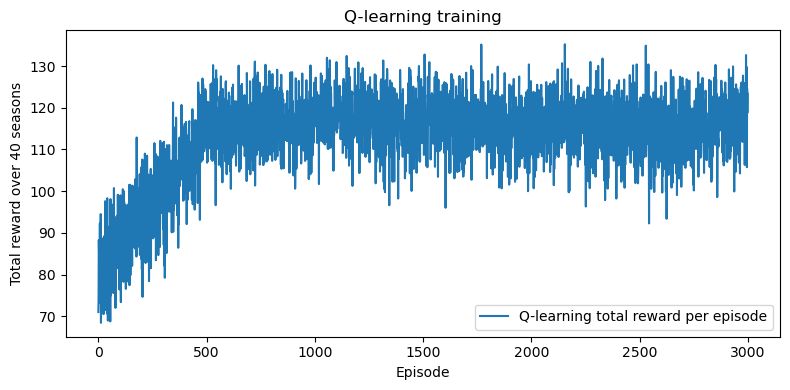

In [15]:
# --------------------------------------------------------
# Train a single Q-learner
# --------------------------------------------------------
SEED = 27
random.seed(SEED)
np.random.seed(SEED)

TRAIN_EPISODES = 3000
TRAIN_SEASONS = 40
EVAL_SEASONS = 10
REWARD_SHAPING_ALPHA = 0.1

q_learner, q_train_rewards = simulate_q_learning(
    crops=crops,
    fields=fields,
    seasons=TRAIN_SEASONS,
    episodes=TRAIN_EPISODES,
    reward_shaping_alpha=REWARD_SHAPING_ALPHA,
    verbose=True,
)

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(q_train_rewards, label="Q-learning total reward per episode")
plt.xlabel("Episode")
plt.ylabel(f"Total reward over {TRAIN_SEASONS} seasons")
plt.title("Q-learning training")
plt.legend()
plt.tight_layout()
plt.show()



The second step is to evaluate the perfomance of the algorithms over multiple seasons and compare them.

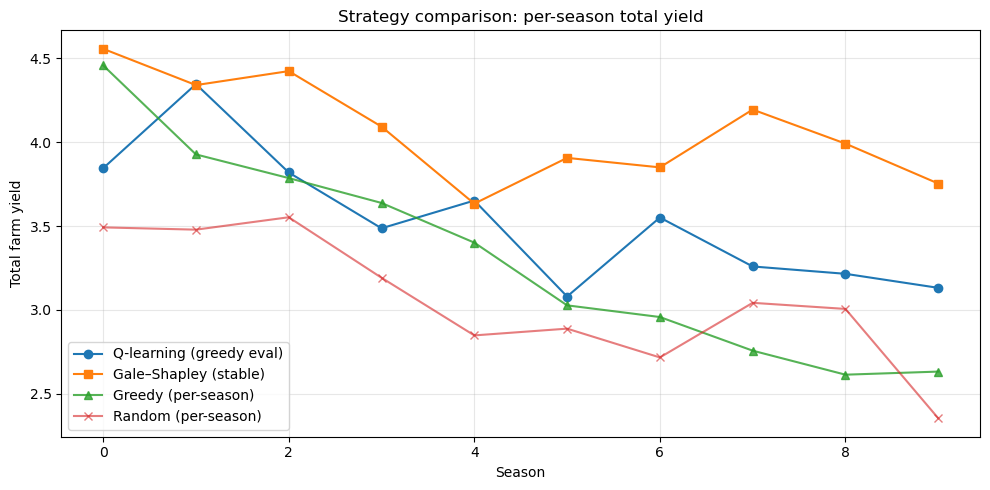

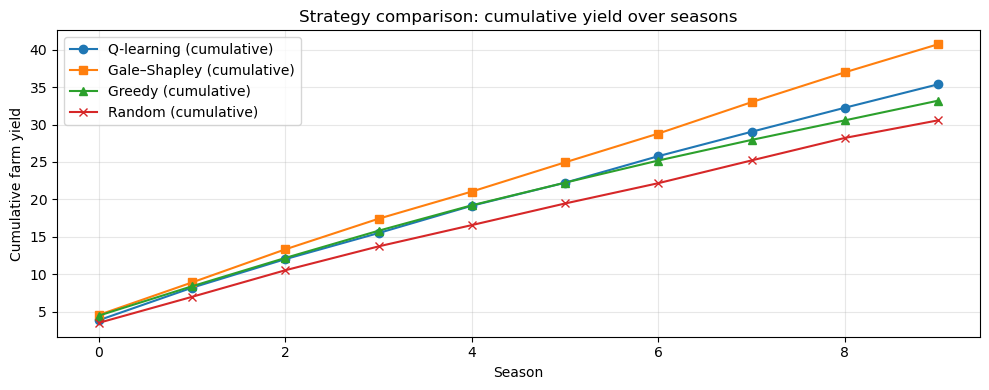

In [16]:
# --------------------------------------------------------
# Evaluate trained Q policy over multiple seasons
# --------------------------------------------------------
q_yields, q_history, q_final_fields = evaluate_q_policy_over_seasons(
    q_learner, crops, fields, EVAL_SEASONS
)

# --------------------------------------------------------
# Gale–Shapley, greedy and random algorithms simulation
# --------------------------------------------------------

# Multi-season baselines (for comparison over time)
stable_yields, stable_history, stable_final_fields = simulate_seasons(
    crops=crops,
    fields=fields,
    seasons=EVAL_SEASONS,
    strategy="stable",
    pref_func=generate_preferences,
    score_func=crop_to_field_score,
)

greedy_yields, greedy_history, greedy_final_fields = simulate_seasons(
    crops=crops,
    fields=fields,
    seasons=EVAL_SEASONS,
    strategy="greedy",
    pref_func=generate_preferences,
    score_func=crop_to_field_score,
)

random_yields, random_history, random_final_fields = simulate_seasons(
    crops=crops,
    fields=fields,
    seasons=EVAL_SEASONS,
    strategy="random",
    pref_func=generate_preferences,
    score_func=crop_to_field_score,
)

# --------------------------------------------------------
# Plot per-season and cumulative yields
# --------------------------------------------------------
seasons_axis = np.arange(EVAL_SEASONS)

plt.figure(figsize=(10, 5))
plt.plot(seasons_axis, q_yields, label="Q-learning (greedy eval)", marker="o")
plt.plot(seasons_axis, stable_yields, label="Gale–Shapley (stable)", marker="s")
plt.plot(seasons_axis, greedy_yields, label="Greedy (per-season)", marker="^", alpha=0.8)
plt.plot(seasons_axis, random_yields, label="Random (per-season)", marker="x", alpha=0.6)
plt.xlabel("Season")
plt.ylabel("Total farm yield")
plt.title("Strategy comparison: per-season total yield")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(seasons_axis, np.cumsum(q_yields), label="Q-learning (cumulative)", marker="o")
plt.plot(seasons_axis, np.cumsum(stable_yields), label="Gale–Shapley (cumulative)", marker="s")
plt.plot(seasons_axis, np.cumsum(greedy_yields), label="Greedy (cumulative)", marker="^")
plt.plot(seasons_axis, np.cumsum(random_yields), label="Random (cumulative)", marker="x")
plt.xlabel("Season")
plt.ylabel("Cumulative farm yield")
plt.title("Strategy comparison: cumulative yield over seasons")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Let's print the rotation tables for the different strategies and the average yields obtained by each of them.

In [17]:
# --------------------------------------------------------
# Summary statistics table
# --------------------------------------------------------
summary = [
    summarize(q_yields, "Q-learning"),
    summarize(stable_yields, "Gale–Shapley (multi-season)"),
    summarize(greedy_yields, "Greedy (multi-season)"),
    summarize(random_yields, "Random (multi-season)"),
]
summary_df = pd.DataFrame(summary).set_index("method")
print("\nSummary over {} seasons:".format(EVAL_SEASONS))
display(summary_df)

# --------------------------------------------------------
# Rotation tables (Q-learning and Gale–Shapley)
# --------------------------------------------------------
print("\nQ-learning rotation (first 6 seasons):")
display(history_to_rotation_table(q_history, max_seasons=6))

print("\nGale–Shapley rotation (first 6 seasons):")
stable_rotation_table = create_rotation_table(stable_history)
display(stable_rotation_table.iloc[:, :min(6, stable_rotation_table.shape[1])])


Summary over 10 seasons:


,total,mean_per_season,std_per_season
method,,,
Q-learning,35.388866,3.538887,0.374217
Gale–Shapley (multi-season),40.748355,4.074835,0.287014
Greedy (multi-season),33.200210,3.320021,0.591347
Random (multi-season),30.571240,3.057124,0.362837



Q-learning rotation (first 6 seasons):


Season,S0,S1,S2,S3,S4,S5
Field,,,,,,
Field0,Soybean,Canola,Pea,Canola,Barley,Soybean
Field1,Barley,Soybean,Barley,Sunflower,Wheat,Sunflower
Field2,Corn,Alfalfa,Corn,Alfalfa,Corn,Alfalfa
Field3,Potato,Pea,Potato,Pea,Potato,Pea
Field4,Pea,Corn,Alfalfa,Corn,Alfalfa,Corn
Field5,Sunflower,Barley,Tomato,Barley,Soybean,Barley
Field6,Wheat,Potato,Soybean,Potato,Pea,Potato
Field7,Alfalfa,Wheat,Sunflower,Tomato,None,Wheat
Field8,Tomato,Sunflower,Canola,Soybean,Canola,Tomato



Gale–Shapley rotation (first 6 seasons):


Season,Season 0,Season 1,Season 2,Season 3,Season 4,Season 5
Field,,,,,,
Field0,Potato,Soybean,Potato,Canola,Corn,Soybean
Field1,Barley,Pea,Wheat,Soybean,Wheat,Sunflower
Field2,Corn,Corn,Alfalfa,Corn,Canola,Wheat
Field3,Alfalfa,Potato,Pea,Barley,Tomato,Barley
Field4,Canola,Alfalfa,Corn,Potato,Alfalfa,Tomato
Field5,Sunflower,Barley,Barley,Tomato,Barley,Corn
Field6,Wheat,Tomato,Tomato,Wheat,Soybean,Potato
Field7,Pea,Wheat,Sunflower,Pea,Potato,Pea
Field8,Soybean,Sunflower,Canola,Alfalfa,Sunflower,Alfalfa


Show the heatmap of the averaged Q-values for each crop-field pair in the ensemble. 

[Ensemble] Training learner 1/3 (seed=0)
[Ensemble] Training learner 2/3 (seed=1)
[Ensemble] Training learner 3/3 (seed=2)


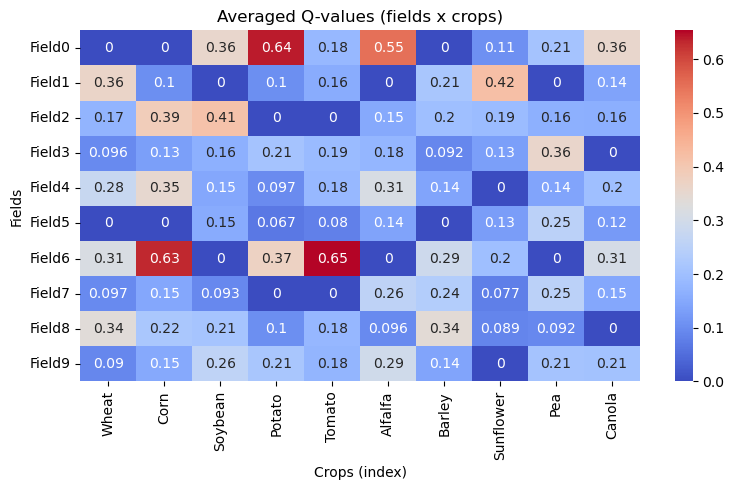

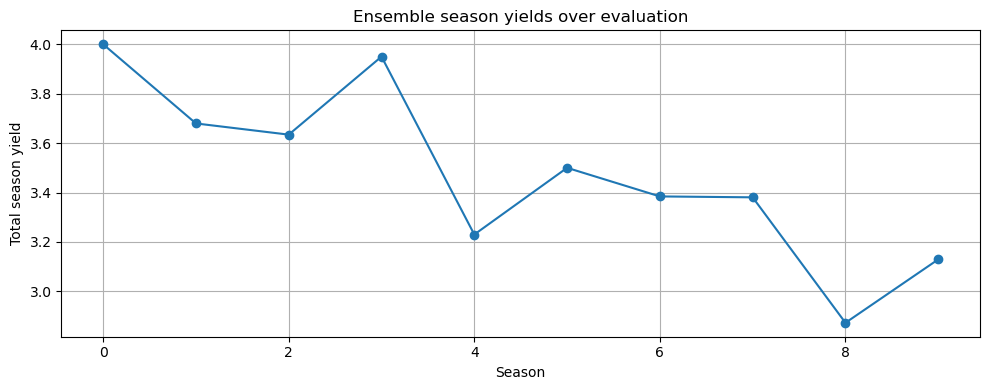

In [18]:
# --------------------------------------------------------
# Train a small ensemble and evaluate it
# --------------------------------------------------------
demo_train_kwargs = {
    "seasons": 10,
    "episodes": 40,
    "reward_shaping_alpha": 0.2,
    "difference_mode": "simple",
    "alpha": 0.05,
    "decay_step": 0.01,
    "verbose": False,
    "reward_clip": 2.0,
}

results = train_ensemble_and_compare(
    crops=crops,
    fields=fields,
    n_learners=3,
    base_seed=0,
    train_kwargs=demo_train_kwargs,
    eval_seasons=10,
    use_hungarian=True,
)

learners = results["learners"]
ensemble_yields = results["ensemble_yields"]
ensemble_history = results["ensemble_history"]

# --------------------------------------------------------
# Q-heatmap and ensemble yield plots
# --------------------------------------------------------

try:
    plot_q_heatmap(learners, crops, fields, title="Averaged Q-values (fields x crops)")
except Exception as e:
    print("Could not plot Q heatmap:", e)

try:
    plt.figure(figsize=(10, 4))
    plt.plot(ensemble_yields, marker="o")
    plt.xlabel("Season")
    plt.ylabel("Total season yield")
    plt.title("Ensemble season yields over evaluation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Could not plot ensemble yields timeline:", e)



Finally, we can also visualize the field-crop assignments over seasons with an interactive plot.

In [19]:
# --------------------------------------------------------
# Interactive timeline (baseline stable matching)
# --------------------------------------------------------
try:
    plot_interactive_fields(stable_history)
except Exception as e:
    print("Could not show interactive timeline:", e)